# ACS 2024 Income Model — Experiment 4 (feature interactions + richer stacking)

A working scaffold derived from **`ML_Model_Building_Template.md`**, wired to **`acs2024v2_income.csv`** — the rich 19-feature ACS 2024 extract produced by `acs2024v2_income_extraction.ipynb`. Run top-to-bottom.

**Dataset:** `acs2024v2_income.csv` — 339,848 employed working-age adults, socio-economic predictors from the 2024 ACS PUMS (1-Year). **v2 adds the `PUMA` sub-state geography feature** to the v1 set, treated like the other high-cardinality categoricals.

| Column | Meaning | Kind |
|---|---|---|
| `AGEP` | Age in years | continuous |
| `WKHP` | Usual hours worked per week | continuous |
| `WKWN` | Weeks worked in past 12 months | continuous |
| `COW` | Class of worker (employment sector) | categorical |
| `SCHL` | Education level (ordinal code) | categorical |
| `MAR` | Marital status | categorical |
| `OCCP` | Occupation code | categorical |
| `INDP` | Industry code | categorical |
| `POBP` | Place of birth | categorical |
| `RELSHIPP` | Relationship to householder | categorical |
| `SEX` | Sex | categorical |
| `RAC1P` | Race group | categorical |
| `HISP` | Hispanic origin | categorical |
| `CIT` | Citizenship status | categorical |
| `NATIVITY` | Nativity (native / foreign-born) | categorical |
| `ENG` | English-speaking ability | categorical |
| `DIS` | Disability | categorical |
| `ST` | State (FIPS code) | categorical |
| `PUMA` | Public Use Microdata Area (sub-state geography, new in v2) | categorical |
| **`WAGP`** | **Target — wages/salary income (scaled)** | continuous |

| Stage | Name | Key concern |
|---|---|---|
| 1 | Environment Setup | Reproducibility |
| 2 | Data Loading & Preview | Understand structure & quality |
| 3 | Data Cleaning | Missing values -> encoding -> imbalance |
| 4 | Graphical EDA | Distributions & relationships |
| 5 | Feature Set + Encoding | All raw + interaction + leak-safe target/freq encoding |
| 6 | Train / Val / Test Split | Stratified, no leakage |
| 7 | Feature Scaling | Fit on train only |
| 8 | Model Architecture | Algorithm choice & hyperparameters |
| 9 | Training | Cross-validation or epoch-based |
| 10 | Learning Curves | Diagnose over/underfitting |
| 11 | Evaluation | Training + test metrics |
| 12 | Save & Inference | Persistence & deployment |

> **Task type:** **regression** — predict `WAGP` from the remaining 19 features. The categorical columns are integer-coded ACS values (`OCCP`, `INDP`, `POBP`, `ST` are high-cardinality), which suits native-categorical gradient-boosted trees.
>
> **Models:** Stages 8-12 benchmark **ten regressors grouped by family** — linear baselines (Ridge, Linear, Lasso), boosted trees (XGBoost, LightGBM, CatBoost), bagging/extra boosting (RandomForest, ExtraTrees, HistGradientBoosting), and a stacking blend of the three boosters. **Experiment 4 builds on Experiment 2 (the current best, Test R² ≈ 0.51)** and pushes the same all-raw + leak-safe-encoding recipe further with three levers: (1) **Mincer earnings-function terms** `AGE2` and `SCHLxAGEP` (Stage 5b); (2) **new tree-visible economic signal** — an `OCCP`×`INDP` *pair* target-encoding plus `OCCP_te`×hours and `INDP_te`×hours interactions (Stage 6b); and (3) a **richer stacking blend** over all six fitted tree learners with a Ridge meta-learner (Stage 9). The question: with the wage signal already known to be feature-bound (exp2/exp3), can interaction features built from the existing columns nudge the ceiling?

## Stage 1 — Environment Setup & Library Imports

Import everything upfront, set display options so nothing is truncated, and fix a global seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

## Stage 2 — Data Loading & Textual Preview

Load `acs2024v2_income.csv` and inspect it textually: shape, head/tail, schema, summary stats, and target distribution. Note any data-quality problems to fix in Stage 3.

In [2]:
# Load dataset
dataset = pd.read_csv("acs2024v2_income.csv", header=0, index_col=None)

TARGET_COLUMN   = "WAGP"
FEATURE_COLUMNS = [c for c in dataset.columns if c != TARGET_COLUMN]
# Continuous vs. categorical (categoricals are integer-coded ACS values).
# OCCP, INDP, POBP, ST are high-cardinality -> prefer native-categorical models.
CONTINUOUS_COLS  = ["AGEP", "WKHP", "WKWN"]
CATEGORICAL_COLS = ["COW", "SCHL", "MAR", "OCCP", "INDP", "POBP", "PUMA", "RELSHIPP",
                    "SEX", "RAC1P", "HISP", "CIT", "NATIVITY", "ENG", "DIS", "ST"]

print("Shape:", dataset.shape, "\n")
print(dataset.head(), "\n")
print(dataset.tail(), "\n")

Shape: (339848, 20) 

   AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP   PUMA  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
0    27    55    52    1    16    5  9620  6170    48   5906        20    1      9    24    1         1    1    2  48  0.054823
1    27    40    52    7    15    5  4251  7770     4   4502        22    1      1     1    1         1    0    2  48  0.040610
2    41    40    52    3    20    3  3655  9480    26   3006        20    2      9     1    1         1    0    1  26  0.034519
3    33    45    52    1    19    5  5420  8191    51  12100        22    2      1     1    1         1    0    2  51  0.040610
4    56    40    52    1    12    5  7315   770    13   1304        20    1      1     1    1         1    0    2  13  0.051778 

        AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP   PUMA  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
339843    48    32    52    1    16    5  4760  5791    37   3700        20

<class 'pandas.DataFrame'>
RangeIndex: 339848 entries, 0 to 339847
Data columns (total 20 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   AGEP      339848 non-null  int64  
 1   WKHP      339848 non-null  int64  
 2   WKWN      339848 non-null  int64  
 3   COW       339848 non-null  int64  
 4   SCHL      339848 non-null  int64  
 5   MAR       339848 non-null  int64  
 6   OCCP      339848 non-null  int64  
 7   INDP      339848 non-null  int64  
 8   POBP      339848 non-null  int64  
 9   PUMA      339848 non-null  int64  
 10  RELSHIPP  339848 non-null  int64  
 11  SEX       339848 non-null  int64  
 12  RAC1P     339848 non-null  int64  
 13  HISP      339848 non-null  int64  
 14  CIT       339848 non-null  int64  
 15  NATIVITY  339848 non-null  int64  
 16  ENG       339848 non-null  int64  
 17  DIS       339848 non-null  int64  
 18  ST        339848 non-null  int64  
 19  WAGP      339848 non-null  float64
dtypes: float64(1), 

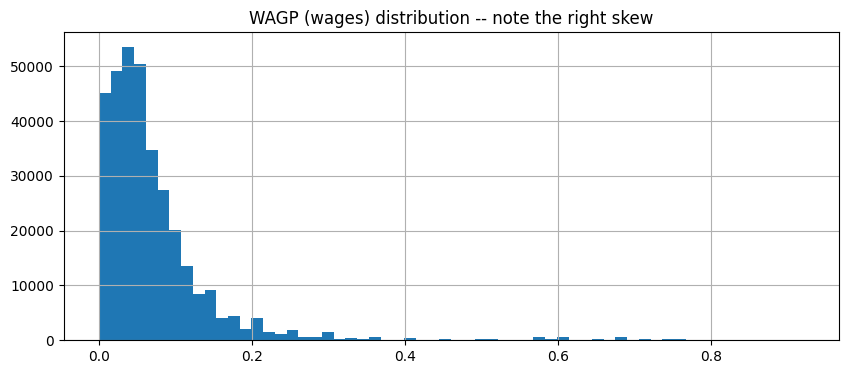

In [3]:
# Structure, dtypes, missing counts, summary stats
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per column:\n", dataset.isna().sum(), "\n")

# Cardinality of categorical columns (flags high-cardinality features for Stage 8)
print("Unique values per categorical column:")
print(dataset[CATEGORICAL_COLS].nunique().sort_values(ascending=False), "\n")

# Target distribution (regression -> describe + histogram)
print(dataset[TARGET_COLUMN].describe())
dataset[TARGET_COLUMN].hist(bins=60, figsize=(10, 4))
plt.title("WAGP (wages) distribution -- note the right skew"); plt.show()

### Stage 2 — Data-quality notes

- **Shape:** 339,848 rows x 20 columns (19 features + `WAGP` target).
- **No missing values:** the extraction step already filtered and sentinel-filled, so Stage 3a is a guard/no-op here.
- **Categoricals are integer-coded:** no string encoding needed. `OCCP`, `INDP`, `POBP`, and `ST` are high-cardinality (hundreds of levels) -> favour native-categorical learners (CatBoost / XGBoost / LightGBM) over one-hot.
- **Target `WAGP` is already scaled** to roughly `[0, 0.92]` (not raw dollars) and is **right-skewed** -> `log1p` transform in Stage 3d; metrics are converted back to dollars (x1e6) in Stage 11.

## Stage 3 — Data Cleaning & Problem Fixing

Fix problems **before** encoding/transformation, in the template order **missing values -> categorical encoding -> class imbalance**, plus a few dataset-specific checks. For `acs2024v2_income.csv` most template steps are guards/no-ops (no nulls, already integer-coded, regression target), so each cell below keeps the **recommended** path active and the **alternatives commented** so the full menu is visible.

**The menu**

| Sub-stage | Recommended (active) | Alternatives (commented) |
|---|---|---|
| 3a Missing values | guard (no nulls present) | KNN / median impute; sentinel level |
| 3b Categorical encoding | keep native, enforce `int` codes | one-hot (low-card only); ordinal (`SCHL`/`ENG`); frequency/target encode (high-card); coarsen to ACS rollups |
| 3c Class imbalance | N/A (continuous target) | bracket `WAGP` + SMOTE/undersample (classification variant) |
| 3d Dataset-specific | duplicate check; `log1p` target | winsorize top-coded tail |

In [4]:
# 3a -- Missing values. acs2024v2_income.csv has NONE, so this is a guard/no-op.
# (The extractor already sentinel-filled non-applicable OCCP/INDP with -1, i.e.
#  "no occupation/industry" is its own category rather than a NaN.)
from sklearn.impute import KNNImputer

cols_with_nulls = [c for c in dataset.columns if dataset[c].isna().any()]
if cols_with_nulls:
    cont_nulls = [c for c in cols_with_nulls if c in CONTINUOUS_COLS]
    cat_nulls  = [c for c in cols_with_nulls if c in CATEGORICAL_COLS]
    if cont_nulls:                                   # continuous -> KNN (or median)
        dataset[cont_nulls] = KNNImputer(n_neighbors=5).fit_transform(dataset[cont_nulls])
    for c in cat_nulls:                              # categorical -> dedicated sentinel
        dataset[c] = dataset[c].fillna(-1)

print("Columns with nulls:", cols_with_nulls)
print("Remaining missing values:", int(dataset.isna().sum().sum()))

Columns with nulls: []
Remaining missing values: 0


In [5]:
# 3b -- Categorical handling. Columns are ALREADY integer-coded ACS values, so no
# string encoding is needed; the real decision is how DOWNSTREAM models treat them.
HIGH_CARD = ["OCCP", "INDP", "POBP", "ST", "PUMA"]                 # 525 / 257 / 222 / 51 levels
LOW_CARD  = [c for c in CATEGORICAL_COLS if c not in HIGH_CARD]

# === RECOMMENDED: keep native categorical, just enforce integer codes ==========
# CatBoost consumes these directly via cat_features; XGBoost/LightGBM via category dtype.
for c in CATEGORICAL_COLS:
    dataset[c] = dataset[c].astype(int)
print("Categoricals enforced as int. High-cardinality levels:",
      {c: int(dataset[c].nunique()) for c in HIGH_CARD})

# === ALTERNATIVE 1 -- One-hot the LOW-cardinality columns only =================
# Good for linear / distance models. NEVER one-hot OCCP/INDP/POBP (-> 1000+ cols).
# dataset = pd.get_dummies(dataset, columns=LOW_CARD, drop_first=True)

# === ALTERNATIVE 2 -- Ordinal encode the genuinely ORDERED columns =============
# Only SCHL (education) and ENG (English ability) have a meaningful order; they are
# already monotonic codes, so use this only if starting from raw string categories.
# from sklearn.preprocessing import OrdinalEncoder
# dataset[["SCHL", "ENG"]] = OrdinalEncoder().fit_transform(dataset[["SCHL", "ENG"]])

# === ALTERNATIVE 3 -- Frequency / target encoding for HIGH-cardinality =========
# For models WITHOUT native categorical support (sklearn RF, linear). Frequency
# encoding is leak-free; target encoding MUST be fit inside CV folds (Stage 6+).
# for c in HIGH_CARD:
#     dataset[c + "_freq"] = dataset[c].map(dataset[c].value_counts(normalize=True))

# === ALTERNATIVE 4 -- Coarsen high-cardinality codes to ACS rollups ============
# dataset["OCCP_grp"] = (dataset["OCCP"] // 100).astype(int)    # ~major occ groups
# dataset["INDP_grp"] = (dataset["INDP"] // 1000).astype(int)   # ~sectors

Categoricals enforced as int. High-cardinality levels: {'OCCP': 525, 'INDP': 257, 'POBP': 222, 'ST': 51, 'PUMA': 1150}


In [6]:
# 3c -- Class imbalance: NOT APPLICABLE (WAGP is a continuous regression target).
# Only relevant for a CLASSIFICATION variant where WAGP is binned into brackets:
# brackets = pd.qcut(dataset[TARGET_COLUMN], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
# then rebalance the resulting classes (SVMSMOTE / RandomUnderSampler).
print("Regression target -- no resampling applied.")

Regression target -- no resampling applied.


In [7]:
# 3d -- Dataset-specific checks beyond the template.

# Duplicate rows: PUMS can legitimately repeat identical feature rows -> inspect, keep.
print("Exact duplicate rows:", int(dataset.duplicated().sum()))

# Outliers / top-coding: Census top-codes very high wages, compressing the right tail.
# WAGP here is already scaled to ~[0, 0.92]. OPTIONAL winsorize at the 99.5th pct:
# cap = dataset[TARGET_COLUMN].quantile(0.995)
# dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(upper=cap)

# Target transform (right-skew): build a log1p target as a SEPARATE series (do NOT
# add it as a feature column). Invert with expm1 before reporting metrics in Stage 11.
y_log = np.log1p(dataset[TARGET_COLUMN])
print("\nlog1p(WAGP) summary:")
print(y_log.describe())

Exact duplicate rows: 650

log1p(WAGP) summary:
count    339848.000000
mean          0.068476
std           0.068479
min           0.000004
25%           0.030003
50%           0.051447
75%           0.086505
max           0.652758
Name: WAGP, dtype: float64


## Stage 4 — Graphical Data Exploration (EDA)

Visualise distributions and relationships before engineering features. The skewed continuous histograms justify the target transform; the grouped-median bars and the focused scatter confirm the headline socio-economic signal (education, hours, sex) is present.

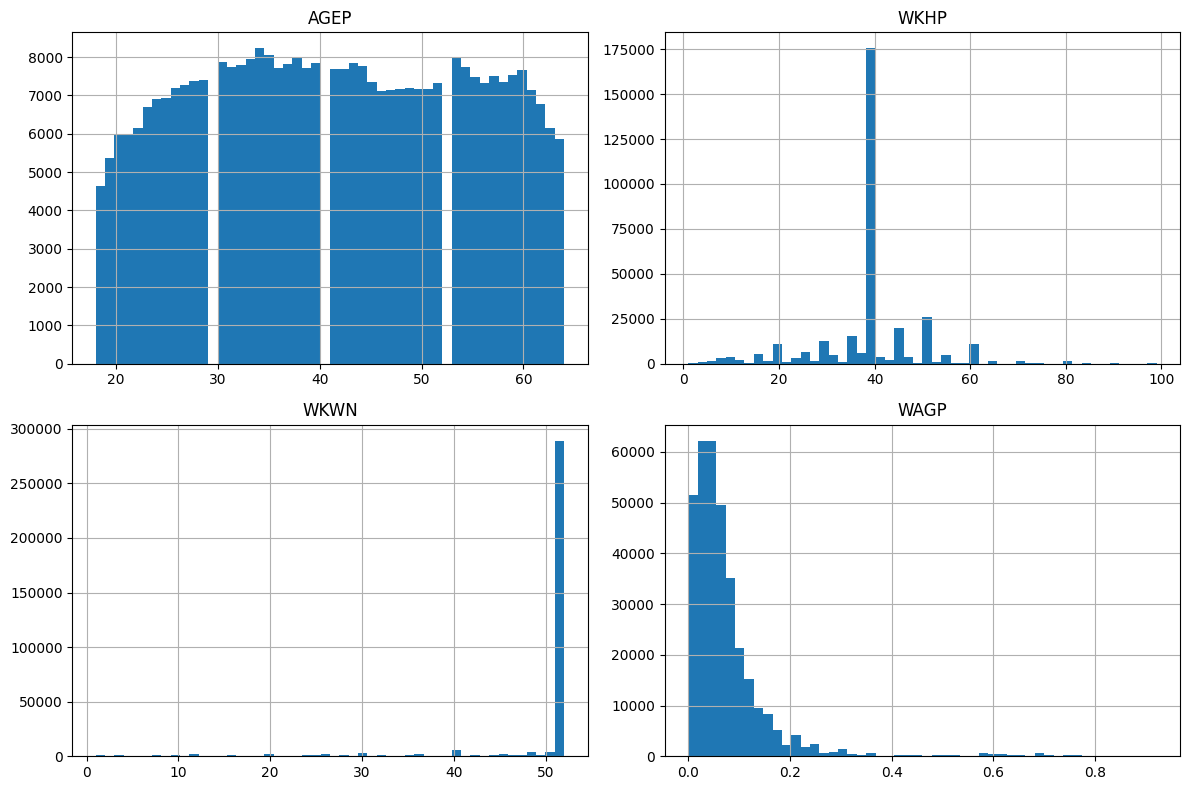

In [8]:
# Distribution of the continuous features + target. (Categorical columns are integer
# CODES, so a numeric histogram of them is not meaningful -- a few key ones are shown
# as grouped medians below instead.)
dataset[CONTINUOUS_COLS + [TARGET_COLUMN]].hist(bins=50, figsize=(12, 8))
plt.tight_layout(); plt.show()

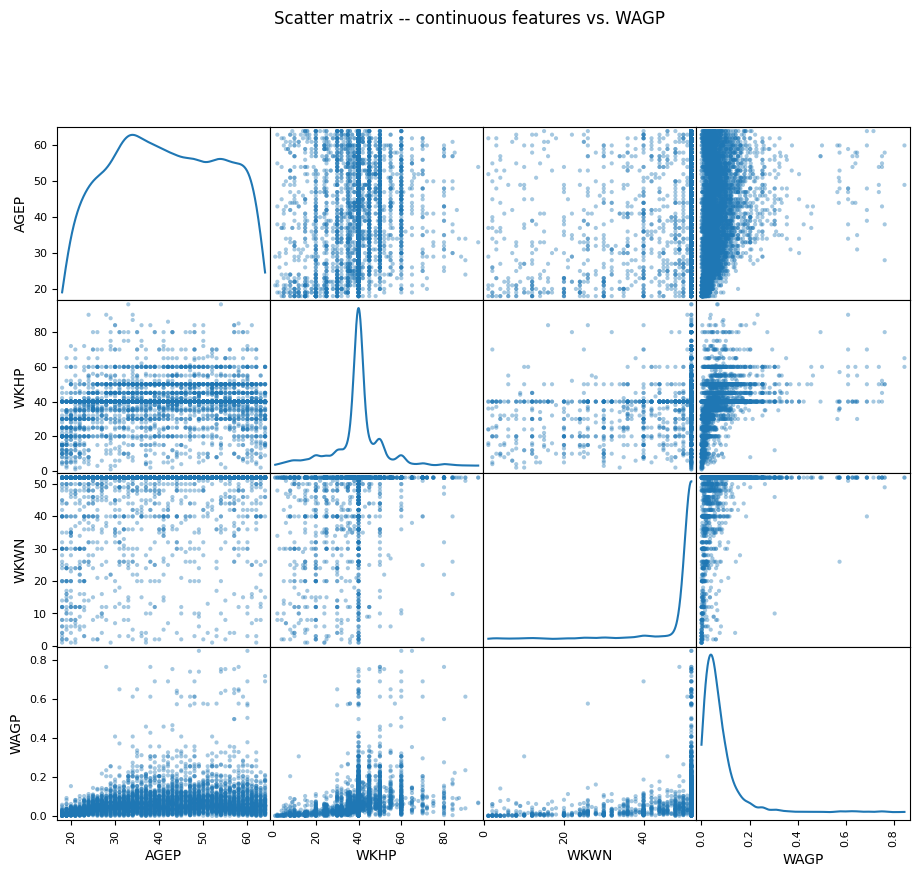

In [9]:
# Pairwise scatter matrix on the continuous features + target (sampled for speed).
from pandas.plotting import scatter_matrix

attrs = CONTINUOUS_COLS + [TARGET_COLUMN]
scatter_matrix(dataset[attrs].sample(5000, random_state=RANDOM_STATE),
               alpha=0.4, figsize=(11, 9), diagonal="kde")
plt.suptitle("Scatter matrix -- continuous features vs. WAGP", y=1.01); plt.show()

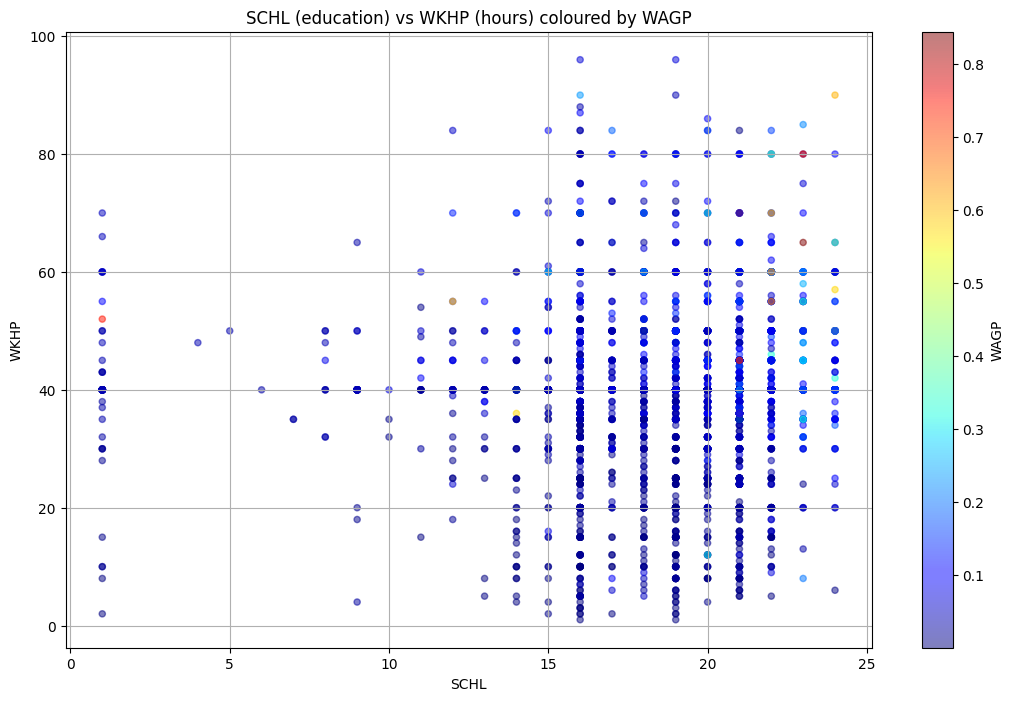

In [10]:
# Focused scatter: education vs. usual hours worked, coloured by wage.
dataset.sample(5000, random_state=RANDOM_STATE).plot(
    kind="scatter", x="SCHL", y="WKHP", c=TARGET_COLUMN, cmap="jet",
    colorbar=True, grid=True, figsize=(13, 8), alpha=0.5)
plt.title("SCHL (education) vs WKHP (hours) coloured by WAGP"); plt.show()

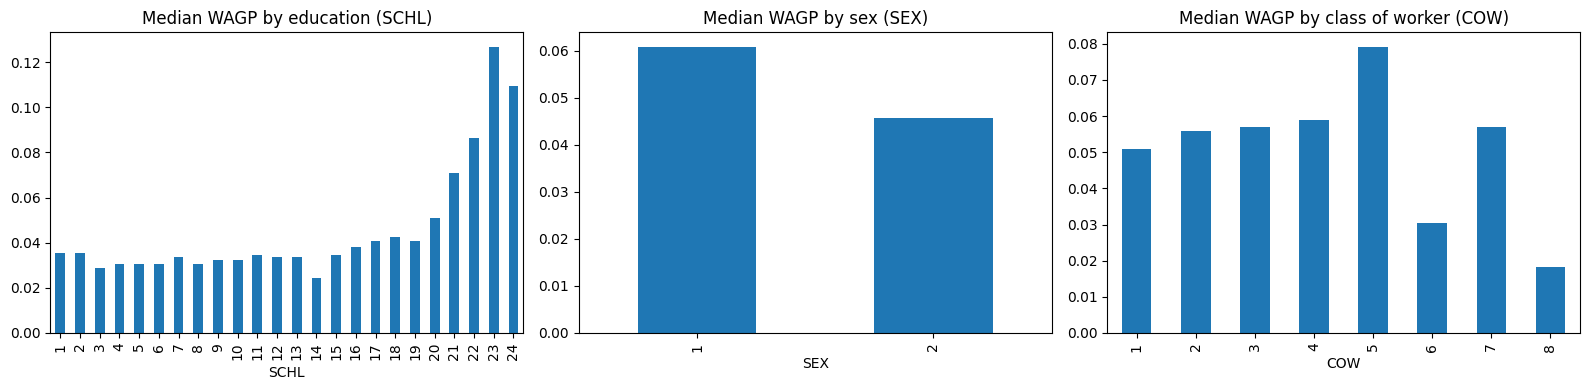

In [11]:
# Signal check: median wage by a few key categoricals (codes ordered on the x-axis).
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
dataset.groupby("SCHL")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[0])
ax[0].set_title("Median WAGP by education (SCHL)")
dataset.groupby("SEX")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[1])
ax[1].set_title("Median WAGP by sex (SEX)")
dataset.groupby("COW")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[2])
ax[2].set_title("Median WAGP by class of worker (COW)")
plt.tight_layout(); plt.show()

## Stage 5 — Feature Set (Experiment 4: more interactions, keep exp2's encodings)

Experiment 4 inherits exp2's winning recipe — **all raw features**, no Select-K-Best, plus the leak-safe Stage-6b encodings — and adds interaction features that the models cannot reconstruct on their own:

- **5b (pre-split, leak-free):** `ANNUAL_HOURS = WKHP × WKWN`, plus two **Mincer earnings-function** terms — `AGE2 = AGEP²` (the concave age–earnings profile) and `SCHLxAGEP = SCHL × AGEP` (education × experience). These mainly help the linear models, which cannot form curvature or products themselves.
- **6b (post-split, leak-safe):** exp2's `OCCP`/`INDP`/`POBP`/`ST` target+frequency encodings, **plus** an `OCCP`×`INDP` *pair* target-encoding (job-within-sector pay) and the interactions `OCCP_te × ANNUAL_HOURS` / `INDP_te × ANNUAL_HOURS` (expected occupational/industry pay scaled by labour supply).

No Select-K-Best. We still rank features by mutual information for insight only.

In [12]:
# 5a -- Feature identification. Experiment 2 keeps ALL raw features; y_sel is the log1p
# target (Stage 3d), trgt_y keeps raw WAGP for dollar-scale reporting later.
feats_X = dataset[FEATURE_COLUMNS].copy()
trgt_y  = pd.DataFrame(dataset[[TARGET_COLUMN]])
y_sel   = y_log
print('feats_X (raw 18 features):', feats_X.shape, '| trgt_y:', trgt_y.shape)

feats_X (raw 18 features): (339848, 19) | trgt_y: (339848, 1)


In [13]:
# 5b -- Feature generation. exp4 keeps exp2's ANNUAL_HOURS and adds two Mincer
# earnings-function terms, all ALONGSIDE every raw feature (heavy lifting is Stage 6b).
feats_X['ANNUAL_HOURS'] = feats_X['WKHP'] * feats_X['WKWN']    # hours/wk x weeks worked
feats_X['AGE2']         = feats_X['AGEP'] ** 2                 # concave age-earnings profile
feats_X['SCHLxAGEP']    = feats_X['SCHL'] * feats_X['AGEP']    # education x experience
GENERATED_COLS = ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']

# Sanity check for inf / NaN introduced by the new features
check = feats_X[CONTINUOUS_COLS + GENERATED_COLS].values
print("'NaN'/'inf' cells:", int(np.isinf(check).sum() + np.isnan(check).sum()))
print('Added features:', GENERATED_COLS, '| feats_X now:', feats_X.shape)

'NaN'/'inf' cells: 0
Added features: ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP'] | feats_X now: (339848, 22)


In [14]:
# 5c -- Feature selection: SKIPPED (no Select-K-Best). Rank by mutual information for
# INSIGHT only, keep EVERY feature.
from sklearn.feature_selection import mutual_info_regression

ALL_FEATURES  = list(feats_X.columns)
discrete_mask = [c in CATEGORICAL_COLS for c in ALL_FEATURES]

samp = feats_X.sample(min(20000, len(feats_X)), random_state=RANDOM_STATE)
mi_scores = pd.Series(
    mutual_info_regression(samp, y_sel.loc[samp.index],
                           discrete_features=discrete_mask, random_state=RANDOM_STATE),
    index=ALL_FEATURES).sort_values(ascending=False)
selected = ALL_FEATURES
print('Mutual information with log(WAGP):')
print(mi_scores.round(4))
print('Experiment 4 keeps all', len(selected), 'base features (encodings/interactions added in Stage 6b).')

Mutual information with log(WAGP):
OCCP            0.3158
ANNUAL_HOURS    0.3000
WKHP            0.2433
SCHLxAGEP       0.1751
INDP            0.1630
SCHL            0.1206
AGE2            0.1180
AGEP            0.1178
WKWN            0.1157
RELSHIPP        0.1063
MAR             0.0575
ST              0.0497
POBP            0.0410
PUMA            0.0365
RAC1P           0.0183
SEX             0.0171
HISP            0.0157
COW             0.0152
ENG             0.0073
CIT             0.0066
DIS             0.0033
NATIVITY        0.0033
dtype: float64
Experiment 4 keeps all 22 base features (encodings/interactions added in Stage 6b).


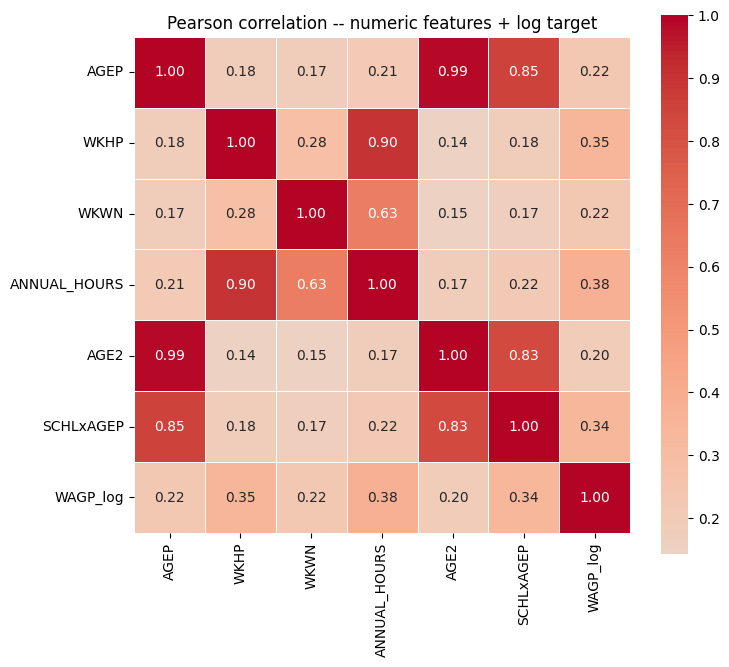

In [15]:
# 5c (heatmap) -- multicollinearity check on the numeric features + target.
numeric_cols = CONTINUOUS_COLS + ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']
corr = pd.concat([feats_X[numeric_cols], y_log.rename('WAGP_log')], axis=1).corr('pearson')

plt.figure(figsize=(8, 7))
sbn.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Pearson correlation -- numeric features + log target'); plt.show()

In [16]:
# Finalise the base feature set: ALL raw features + the Stage-5b interactions
# (ANNUAL_HOURS, AGE2, SCHLxAGEP). Leak-safe encodings/interactions are appended in Stage 6b.
useful_feats_X = feats_X[selected].copy()
print('Base feature set:', list(useful_feats_X.columns))
print('useful_feats_X:', useful_feats_X.shape)

Base feature set: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']
useful_feats_X: (339848, 22)


## Stage 6 — Train / Validation / Test Split

Regression target -> a plain shuffled `train_test_split` (an optional `qcut`-bin stratification is shown to balance income *ranges*). A validation slice is carved from train for early stopping. Targets are `log1p(WAGP)`; the `*_raw` series recover the (scaled) WAGP axis via `expm1`, then Stage 11 multiplies by 1e6 for dollars.

In [17]:
from sklearn.model_selection import train_test_split

X = useful_feats_X
y = y_sel                                   # = y_log, index-aligned with X

# Categorical subset that survived selection -> native categorical handling in Stage 8.
CAT_FEATURES = [c for c in X.columns if c in CATEGORICAL_COLS]
print("Categorical features carried into the models:", CAT_FEATURES)

# Primary 80/20 train-test split (shuffled).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Optional: balance income RANGES across splits instead (uncomment to stratify):
# strat_bins = pd.qcut(y, q=10, labels=False)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strat_bins)

# Carve a validation slice out of train (early stopping).
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Raw-axis targets aligned to each split (expm1 inverts the log1p), for Stage 11.
y_train_raw = np.expm1(y_train)
y_val_raw   = np.expm1(y_val)
y_test_raw  = np.expm1(y_test)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Categorical features carried into the models: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']


X_train: (217502, 22) | X_val: (54376, 22) | X_test: (67970, 22)


## Stage 6b — Leak-safe encoding & interactions (exp4 extends exp2)

All fit on the **training split only**, then mapped onto val/test (unseen levels fall back to the global mean / 0):

- **Target encoding** (exp2) — smoothed mean `log1p(WAGP)` per level of `OCCP`/`INDP`/`POBP`/`ST`; train rows use **5-fold out-of-fold** means, val/test use full-train means.
- **Frequency encoding** (exp2) — each level's share of training rows.
- **`OCCP`×`INDP` pair target-encoding** (new) — smoothed mean log-wage for the *(occupation, industry)* pair, i.e. "what does this job pay *in this sector*"; heavier smoothing (`PAIR_SMOOTH`) tames sparse pairs.
- **Encoded × hours interactions** (new) — `OCCP_te × ANNUAL_HOURS` and `INDP_te × ANNUAL_HOURS`: expected occupational / industry pay scaled by labour supply. Built from the leak-safe `_te` columns, so they stay leak-safe.

These numeric columns are consumed by the trees (and the stack); the linear models keep their one-hot pipeline.

In [18]:
# Stage 6b -- exp4 EXTENDS exp2's leak-safe encodings (everything fit on TRAIN only).
from sklearn.model_selection import KFold

HIGH_CARD_TE = ['OCCP', 'INDP', 'POBP', 'ST', 'PUMA']
GLOBAL_MEAN  = float(y_train.mean())
SMOOTH       = 20.0       # per-level shrink toward the global mean
PAIR_SMOOTH  = 50.0       # heavier shrink for the sparse OCCP x INDP pair

# Transient OCCP x INDP pair key on every split (encoded below, never kept as a feature).
for frame in (X_train, X_val, X_test):
    frame['_OCCP_INDP'] = frame['OCCP'].astype('int64') * 100000 + frame['INDP'].astype('int64')

def _smoothed(xc, yc, col, smooth):
    g = yc.groupby(xc[col]); m = g.mean(); n = g.count()
    return (m * n + GLOBAL_MEAN * smooth) / (n + smooth)

# columns to target-encode -> (source col, smoothing, output name)
TE_SPEC = [(c, SMOOTH, c + '_te') for c in HIGH_CARD_TE] + [('_OCCP_INDP', PAIR_SMOOTH, 'OCCPINDP_te')]

# 1) OUT-OF-FOLD target encoding on the training rows (no row sees its own target)
for _src, _s, out in TE_SPEC:
    X_train[out] = GLOBAL_MEAN
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for tr, va in kf.split(X_train):
    va_idx = X_train.index[va]
    for src, smooth, out in TE_SPEC:
        fmap = _smoothed(X_train.iloc[tr], y_train.iloc[tr], src, smooth)
        X_train.loc[va_idx, out] = X_train.loc[va_idx, src].map(fmap).fillna(GLOBAL_MEAN)

# 2) FULL-train maps -> val/test target encoding; frequency encoding for the single codes
full_maps = {src: _smoothed(X_train, y_train, src, smooth) for src, smooth, _o in TE_SPEC}
freq_maps = {c: X_train[c].value_counts(normalize=True) for c in HIGH_CARD_TE}
ENC_COLS  = []
for src, _smooth, out in TE_SPEC:
    X_val[out]  = X_val[src].map(full_maps[src]).fillna(GLOBAL_MEAN)
    X_test[out] = X_test[src].map(full_maps[src]).fillna(GLOBAL_MEAN)
    ENC_COLS.append(out)
for c in HIGH_CARD_TE:
    for frame in (X_train, X_val, X_test):
        frame[c + '_freq'] = frame[c].map(freq_maps[c]).fillna(0.0)
    ENC_COLS.append(c + '_freq')

# 3) exp4 interactions: expected occ/ind pay (target-enc) x labour supply (annual hours)
for frame in (X_train, X_val, X_test):
    frame['OCCPte_x_HOURS'] = frame['OCCP_te'] * frame['ANNUAL_HOURS']
    frame['INDPte_x_HOURS'] = frame['INDP_te'] * frame['ANNUAL_HOURS']
ENC_COLS += ['OCCPte_x_HOURS', 'INDPte_x_HOURS']

# Drop the transient pair key; align column order across splits (CatBoost matches by position).
for frame in (X_train, X_val, X_test):
    frame.drop(columns='_OCCP_INDP', inplace=True)
X_val  = X_val[X_train.columns]
X_test = X_test[X_train.columns]

print('Added leak-safe encodings + interactions:', ENC_COLS)
print('X_train:', X_train.shape, '| X_val:', X_val.shape, '| X_test:', X_test.shape)

Added leak-safe encodings + interactions: ['OCCP_te', 'INDP_te', 'POBP_te', 'ST_te', 'PUMA_te', 'OCCPINDP_te', 'OCCP_freq', 'INDP_freq', 'POBP_freq', 'ST_freq', 'PUMA_freq', 'OCCPte_x_HOURS', 'INDPte_x_HOURS']
X_train: (217502, 35) | X_val: (54376, 35) | X_test: (67970, 35)


## Stage 7 — Feature Scaling / Normalisation

**Primary (tree) path: no scaling.** Gradient-boosted trees are scale-invariant, the target is already `log1p`-transformed, and scaling would corrupt the integer category codes. The commented **DL / linear branch** shows the leakage-safe pattern: fit on **train only**, transform **numeric features only**.

In [19]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler

# === PRIMARY (tree) path: NO scaling -- pass through ===========================
X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test
y_train_sc, y_val_sc, y_test_sc = y_train, y_val, y_test
print("Tree path: features passed through unscaled.")

# === ALTERNATIVE (DL / linear branch): scale NUMERIC features only =============
# NUMERIC_COLS = [c for c in X_train.columns if c not in CAT_FEATURES]
# scaler_X = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE)
# scaler_X.fit(X_train[NUMERIC_COLS])
# def _scale(df):
#     out = df.copy(); out[NUMERIC_COLS] = scaler_X.transform(df[NUMERIC_COLS]); return out
# X_train_sc, X_val_sc, X_test_sc = _scale(X_train), _scale(X_val), _scale(X_test)

Tree path: features passed through unscaled.


## Stage 8 — Model Selection, Architecture & Compilation

Ten regressors are configured and benchmarked, grouped by family, all on the same selected features and the same `log1p(WAGP)` target:

**1. Linear baselines — Ridge / plain Linear / Lasso.** A floor for the comparison. They can't consume the integer ACS codes directly (those codes are *nominal* — a larger `OCCP` isn't "more"), so each is wrapped in a `Pipeline` whose `ColumnTransformer` **standardises the numeric features and one-hot encodes the categoricals**, fit on the training fold only (leakage-safe).

**2. Boosted trees — XGBoost / LightGBM / CatBoost.** Matched hyperparameters (`~2000` trees, `lr=0.05`, `max_depth=8`, L2, early stopping) so differences reflect the *algorithm*. All three ingest the categoricals **natively**, including high-cardinality `OCCP`/`INDP`/`ST`:
- **CatBoost** — `cat_features` (ordered boosting). **XGBoost** — `enable_categorical=True`. **LightGBM** — `categorical_feature=` (both need pandas `category` dtype).

**3. Bagging & extra boosting — RandomForest / ExtraTrees / HistGradientBoosting.** Contrasting tree paradigms (bagging vs. boosting) **without** native high-cardinality support — they read the integer codes as *ordinal*, so they're the "no native categoricals" comparison point. HistGB's native categorical mode caps at 255 categories, which `OCCP`(525)/`INDP`(257) exceed, so it too treats the codes as ordinal.

**4. Stacking ensemble — blend of XGBoost + LightGBM + CatBoost.** A `StackedGBM` holdout-blender: the three fitted boosters predict on the held-out validation split, and a linear meta-learner learns how to weight them. This is the one model most likely to edge past the individual boosters. (A holdout blend is used instead of full CV stacking because re-fitting three heavy boosters across CV folds on 217k rows is far more expensive for a marginal gain.)

In [20]:
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

cat_model = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=10,
    loss_function="RMSE", eval_metric="RMSE", random_state=RANDOM_STATE,
    early_stopping_rounds=100, verbose=400)

xgb_model = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=10, tree_method="hist",
    enable_categorical=True, early_stopping_rounds=100,
    random_state=RANDOM_STATE, verbosity=0)

lgb_model = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=10,
    random_state=RANDOM_STATE, verbose=-1)

print("Configured CatBoost, XGBoost, LightGBM.")
print("Categorical features:", CAT_FEATURES)

# --- Linear baselines: Ridge / Linear / Lasso --------------------------------
# Unlike the trees, linear models can't read the integer ACS codes directly: those
# codes are NOMINAL (a higher OCCP number isn't "more"), so they must be one-hot'd,
# and the numeric features must be standardised. A ColumnTransformer does both and is
# fit INSIDE each pipeline -> on the training fold only, so the split stays leak-free.
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC_FOR_LINEAR = [c for c in X_train.columns if c not in CAT_FEATURES]   # raw numerics + interaction + encodings
linear_pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FOR_LINEAR),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),     # sparse -> high-card OK
])

def make_linear(estimator):
    """Wrap a linear estimator with the shared scale + one-hot preprocessor."""
    return Pipeline([("prep", linear_pre), ("model", estimator)])

ridge_model  = make_linear(Ridge(alpha=1.0))
linear_model = make_linear(LinearRegression())
lasso_model  = make_linear(Lasso(alpha=1e-4, max_iter=3000, random_state=RANDOM_STATE))

print("\nConfigured Ridge, LinearRegression, Lasso (StandardScaler + OneHotEncoder pipeline).")
print("Numeric  ->", NUMERIC_FOR_LINEAR)
print("One-hot  ->", CAT_FEATURES)

# --- Bagging & extra-boosting baselines: RandomForest / ExtraTrees / HistGB ---
# None of these have native high-cardinality categorical support, so they read the
# integer ACS codes as ORDINAL numbers (a known limitation vs CatBoost/LightGBM). We
# still feed the plain integer frames -- one-hot would explode OCCP(525)/INDP(257) and
# is unnecessary for trees. This makes them a fair "no native categoricals" contrast.
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              HistGradientBoostingRegressor)

rf_model = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)

et_model = ExtraTreesRegressor(
    n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)

# HistGB's native categorical mode caps at 255 categories/feature, but OCCP(525)/INDP(257)
# exceed that -> we let it treat the codes as ordinal and use its built-in early stopping
# (internal validation split carved from train).
hgb_model = HistGradientBoostingRegressor(
    max_iter=2000, learning_rate=0.05, max_depth=8, l2_regularization=10,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=50,
    random_state=RANDOM_STATE)

print("\nConfigured RandomForest, ExtraTrees, HistGradientBoosting (plain integer codes).")

# --- Stacking ensemble of the three boosters (XGB + LightGBM + CatBoost) ------
# Holdout BLEND (cheaper than full CV stacking on 217k x 3 heavy models): the three
# already-fitted boosters predict on the held-out VALIDATION split, and a linear
# meta-learner learns how to weight them. Leakage-safe -- bases train on X_train, the
# meta trains on X_val, and everything is finally scored on the untouched X_test.
class StackedGBM:
    """Blend XGBoost + LightGBM + CatBoost predictions with a linear meta-learner.

    predict() accepts the PLAIN integer frame and rebuilds the category-dtype copy that
    XGBoost/LightGBM need, casting with the TRAINING categories so the integer->code
    mapping stays consistent (unseen levels become NaN = missing, handled natively)."""
    def __init__(self, base_models, cat_dtypes, meta=None):
        self.base_models = base_models      # list of (name, fitted_model, needs_category)
        self.cat_dtypes  = cat_dtypes       # {col: training CategoricalDtype}
        self.meta = meta if meta is not None else LinearRegression()

    def _stack(self, X):
        Xc = X.copy()
        for c, dt in self.cat_dtypes.items():
            Xc[c] = Xc[c].astype(dt)        # cast with the train category set
        preds = [m.predict(Xc if need_cat else X)
                 for _, m, need_cat in self.base_models]
        return np.column_stack(preds)

    def fit(self, X_blend, y_blend):
        self.meta.fit(self._stack(X_blend), y_blend)
        return self

    def predict(self, X):
        return self.meta.predict(self._stack(X))

print("Defined StackedGBM blender (meta-learner: LinearRegression).")

Configured CatBoost, XGBoost, LightGBM.
Categorical features: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']

Configured Ridge, LinearRegression, Lasso (StandardScaler + OneHotEncoder pipeline).
Numeric  -> ['AGEP', 'WKHP', 'WKWN', 'ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP', 'OCCP_te', 'INDP_te', 'POBP_te', 'ST_te', 'PUMA_te', 'OCCPINDP_te', 'OCCP_freq', 'INDP_freq', 'POBP_freq', 'ST_freq', 'PUMA_freq', 'OCCPte_x_HOURS', 'INDPte_x_HOURS']
One-hot  -> ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'PUMA', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']



Configured RandomForest, ExtraTrees, HistGradientBoosting (plain integer codes).
Defined StackedGBM blender (meta-learner: LinearRegression).


## Stage 9 — Training

Models are fit in family order. The **linear baselines** and the **RandomForest / ExtraTrees / HistGradientBoosting** trees fit on the plain integer training split (the linear pipelines scale + one-hot internally; HistGB carves its own early-stopping slice). The three **boosters** then train on the `log1p` target with early stopping against our validation split — CatBoost via `Pool`, XGBoost/LightGBM on **`category`-dtype copies** (built once below, with val/test cast to the *training* categories so the codes stay consistent). Finally the **`StackedGBM`** blender fits its linear meta-learner on the boosters' validation-set predictions. The `MODELS` dict is assembled in benchmark order and records the frame each model predicts on.

In [21]:
import time, lightgbm as lgb

# Category-dtype copies for XGBoost / LightGBM. Build the TRAIN frame first to fix the
# category set, then cast val/test to the SAME categories so the integer->code mapping is
# consistent across splits (levels unseen in train become NaN = missing, handled natively).
def as_category(df, ref=None):
    out = df.copy()
    for c in CAT_FEATURES:
        out[c] = out[c].astype("category") if ref is None else out[c].astype(ref[c].dtype)
    return out
X_train_cat = as_category(X_train)
X_val_cat   = as_category(X_val,  ref=X_train_cat)
X_test_cat  = as_category(X_test, ref=X_train_cat)

# --- Linear baselines (own scale + one-hot pipeline; no validation / early stopping) ---
for nm, lm in [("Ridge", ridge_model), ("Linear", linear_model), ("Lasso", lasso_model)]:
    t0 = time.time(); lm.fit(X_train, y_train)
    print(f"{nm:20s} trained {time.time()-t0:6.1f}s")

# --- Bagging / HistGB baselines (plain integer frames; trees split on the codes) ---
for nm, tm in [("RandomForest", rf_model), ("ExtraTrees", et_model),
               ("HistGradientBoosting", hgb_model)]:
    t0 = time.time(); tm.fit(X_train, y_train)
    print(f"{nm:20s} trained {time.time()-t0:6.1f}s")

# --- CatBoost (native Pool) ---
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_val,   y_val,   cat_features=CAT_FEATURES)
t0 = time.time(); cat_model.fit(train_pool, eval_set=val_pool)
print(f"{'CatBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {cat_model.get_best_iteration()}")

# --- XGBoost ---
t0 = time.time(); xgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], verbose=False)
print(f"{'XGBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {xgb_model.best_iteration}")

# --- LightGBM ---
t0 = time.time()
lgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], eval_metric="rmse",
              categorical_feature=CAT_FEATURES,
              callbacks=[lgb.early_stopping(100, verbose=False)])
print(f"{'LightGBM':20s} trained {time.time()-t0:6.1f}s | best_iter {lgb_model.best_iteration_}")

# --- Stacking ensemble (exp4): blend ALL SIX fitted tree learners on the held-out
# validation split, with a regularised Ridge meta-learner (exp2 used 3 boosters + Linear). ---
cat_dtypes  = {c: X_train_cat[c].dtype for c in CAT_FEATURES}
stack_model = StackedGBM(
    base_models=[("XGBoost", xgb_model, True),
                 ("LightGBM", lgb_model, True),
                 ("CatBoost", cat_model, False),
                 ("HistGradientBoosting", hgb_model, False),
                 ("RandomForest", rf_model, False),
                 ("ExtraTrees", et_model, False)],
    cat_dtypes=cat_dtypes, meta=Ridge(alpha=1.0))
t0 = time.time(); stack_model.fit(X_val, y_val)   # meta learns weights on out-of-base-sample preds
w = stack_model.meta.coef_
print(f"{'Stacking(6 trees)':20s} trained {time.time()-t0:6.1f}s | meta weights " +
      ", ".join(f"{n}={wi:+.2f}" for (n, _m, _c), wi in zip(stack_model.base_models, w)))

# Benchmark order: linear -> original boosters -> bagging/HistGB -> stacking (capstone).
# Each entry maps a model to the frames it predicts on in Stage 11.
MODELS = {
    "Ridge":    (ridge_model,  X_train,     X_test),
    "Linear":   (linear_model, X_train,     X_test),
    "Lasso":    (lasso_model,  X_train,     X_test),
    "XGBoost":  (xgb_model,    X_train_cat, X_test_cat),
    "LightGBM": (lgb_model,    X_train_cat, X_test_cat),
    "CatBoost": (cat_model,    X_train,     X_test),
    "RandomForest":         (rf_model,    X_train, X_test),
    "ExtraTrees":           (et_model,    X_train, X_test),
    "HistGradientBoosting": (hgb_model,   X_train, X_test),
    "Stacking(GBMs)":       (stack_model, X_train, X_test),
}

Ridge                trained    4.7s


Linear               trained    9.6s


Lasso                trained    2.0s


RandomForest         trained   27.0s


ExtraTrees           trained   11.4s


...

1999:	learn: 0.0425755	test: 0.0472383	best: 0.0472383 (1999)	total: 3m 53s	remaining: 0us

bestTest = 0.04723833796
bestIteration = 1999



CatBoost             trained  234.0s | best_iter 1999


XGBoost              trained    3.6s | best_iter 183


LightGBM             trained    2.0s | best_iter 236


Stacking(6 trees)    trained    1.0s | meta weights XGBoost=+0.07, LightGBM=+0.26, CatBoost=+0.35, HistGradientBoosting=+0.23, RandomForest=-0.07, ExtraTrees=+0.18


## Stage 10 — Learning Curve Visualisation

Left: CatBoost **train vs. validation** RMSE (the template's over/underfit diagnosis — a widening gap signals overfitting). Right: **validation RMSE for the three boosted-tree algorithms** overlaid, so their convergence and early-stopping points are directly comparable. (The linear baselines fit in closed form / coordinate descent with no boosting iterations, so they have no learning curve.) All curves are on the `log1p` target axis.

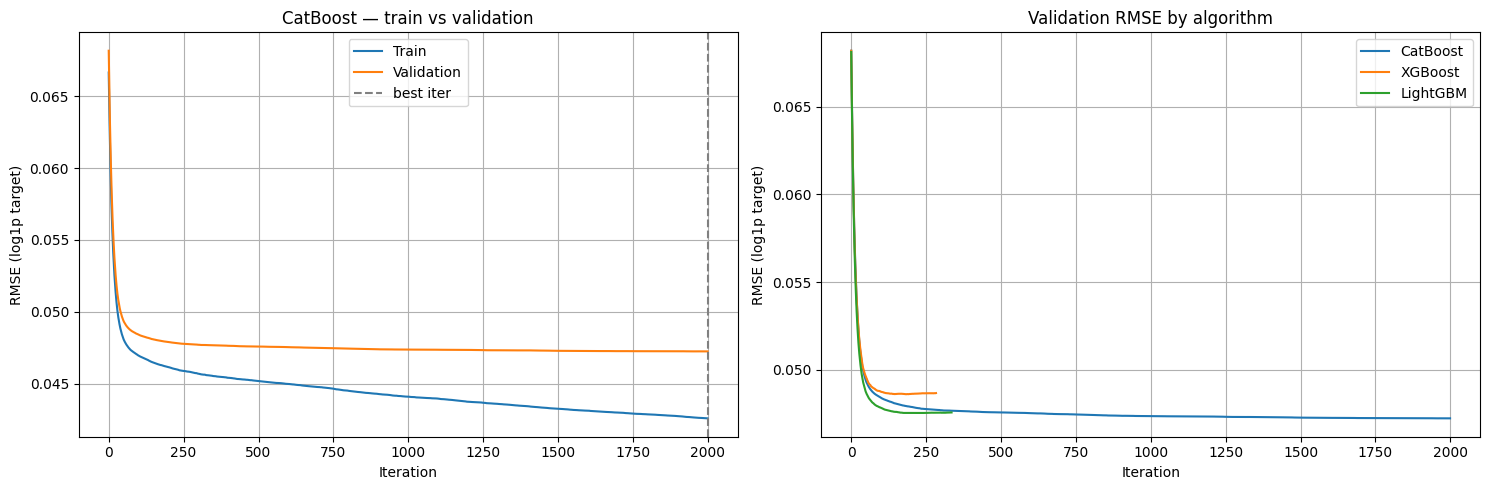

In [22]:
ev_cat = cat_model.get_evals_result()
ev_xgb = xgb_model.evals_result()
ev_lgb = lgb_model.evals_result_

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: CatBoost train vs validation
ax[0].plot(ev_cat["learn"]["RMSE"], label="Train")
ax[0].plot(ev_cat["validation"]["RMSE"], label="Validation")
ax[0].axvline(cat_model.get_best_iteration(), ls="--", c="grey", label="best iter")
ax[0].set_title("CatBoost — train vs validation")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("RMSE (log1p target)")
ax[0].legend(); ax[0].grid()

# Right: validation RMSE overlay across the three algorithms
ax[1].plot(ev_cat["validation"]["RMSE"],   label="CatBoost")
ax[1].plot(ev_xgb["validation_0"]["rmse"], label="XGBoost")
ax[1].plot(ev_lgb["valid_0"]["rmse"],      label="LightGBM")
ax[1].set_title("Validation RMSE by algorithm")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("RMSE (log1p target)")
ax[1].legend(); ax[1].grid()

plt.tight_layout(); plt.show()

## Stage 11 — Evaluation on Training & Test Sets

Score every model on **both** train and test so the train-vs-test gap is visible. Predictions are made on the `log1p` axis, inverted with `expm1`, then multiplied by `WAGP_TO_DOLLARS = 1e6` to report **MAE / RMSE in dollars** (the extractor stored `WAGP` as adjusted dollars / 1e6). `R²` / Explained Variance are scale-free. The printed rows match the Experiment-Log format; `results_df` collects them.

In [23]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, r2_score)

WAGP_TO_DOLLARS = 1_000_000
MODS = "exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack"

rows = []
print("| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |")
print("|---|---|---|---|---|---|---|---|")
for name, (m, X_tr, X_te) in MODELS.items():           # MODELS is in benchmark order
    p_tr = np.expm1(m.predict(X_tr)) * WAGP_TO_DOLLARS
    p_te = np.expm1(m.predict(X_te)) * WAGP_TO_DOLLARS
    yt_tr = y_train_raw.values * WAGP_TO_DOLLARS
    yt_te = y_test_raw.values  * WAGP_TO_DOLLARS
    row = {
        "Algorithm": name, "Modifications": MODS,
        "Train MAE":  mean_absolute_error(yt_tr, p_tr),
        "Train RMSE": mean_squared_error(yt_tr, p_tr) ** 0.5,
        "Train R2":   r2_score(yt_tr, p_tr),
        "Test MAE":   mean_absolute_error(yt_te, p_te),
        "Test RMSE":  mean_squared_error(yt_te, p_te) ** 0.5,
        "Test R2":    r2_score(yt_te, p_te),
    }
    rows.append(row)
    print(f"| {name} | {MODS} | {row['Train MAE']:,.2f} | {row['Train RMSE']:,.2f} | "
          f"{row['Train R2']:.2f} | {row['Test MAE']:,.2f} | {row['Test RMSE']:,.2f} | {row['Test R2']:.2f} |")

# Keep rows in the benchmark order (Ridge -> Linear -> Lasso -> XGBoost -> LightGBM -> CatBoost);
# the best model is picked by Test R2 in Stage 12 via idxmax, not by row position.
results_df = pd.DataFrame(rows)
results_df

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|


| Ridge | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 31,022.21 | 60,856.14 | 0.46 | 31,388.33 | 62,699.51 | 0.44 |


| Linear | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 31,184.18 | 60,639.74 | 0.46 | 31,336.08 | 62,815.63 | 0.43 |


| Lasso | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 31,733.87 | 62,802.95 | 0.42 | 31,790.95 | 63,379.95 | 0.42 |


| XGBoost | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 19,099.57 | 36,184.58 | 0.81 | 28,526.30 | 60,398.02 | 0.48 |


...

| RandomForest | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 17,887.34 | 41,609.38 | 0.75 | 28,745.90 | 59,979.04 | 0.48 |


| ExtraTrees | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 16,838.57 | 39,306.74 | 0.77 | 28,255.07 | 59,543.53 | 0.49 |


| HistGradientBoosting | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 26,409.39 | 53,544.22 | 0.58 | 28,203.52 | 59,087.90 | 0.50 |


| Stacking(GBMs) | exp2 base + Mincer terms + OCCPxINDP pair-enc + te*hours + 6-tree stack | 24,119.35 | 49,175.07 | 0.65 | 27,824.02 | 58,502.16 | 0.51 |


,Algorithm,Modifications,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Ridge,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,31022.211341,60856.138571,0.457559,31388.330489,62699.512184,0.436192
1,Linear,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,31184.182623,60639.738153,0.461410,31336.082741,62815.632444,0.434101
2,Lasso,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,31733.870900,62802.953746,0.422298,31790.946626,63379.950306,0.423888
3,XGBoost,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,19099.565511,36184.584960,0.808225,28526.299578,60398.018204,0.476823
4,LightGBM,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,24923.246233,49609.029679,0.639533,28261.590084,59146.785098,0.498275
5,CatBoost,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,26463.542861,54418.893214,0.566246,27926.731583,58663.813417,0.506436
6,RandomForest,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,17887.339729,41609.383497,0.746413,28745.902233,59979.035652,0.484057
7,ExtraTrees,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,16838.574196,39306.738442,0.773704,28255.067807,59543.534594,0.491522
8,HistGradientBoosting,exp2 base + Mincer terms + OCCPxINDP pair-enc ...,26409.389800,53544.217835,0.580078,28203.519849,59087.896666,0.499274
9,Stacking(GBMs),exp2 base + Mincer terms + OCCPxINDP pair-enc ...,24119.350168,49175.074596,0.645812,27824.024559,58502.160193,0.509152


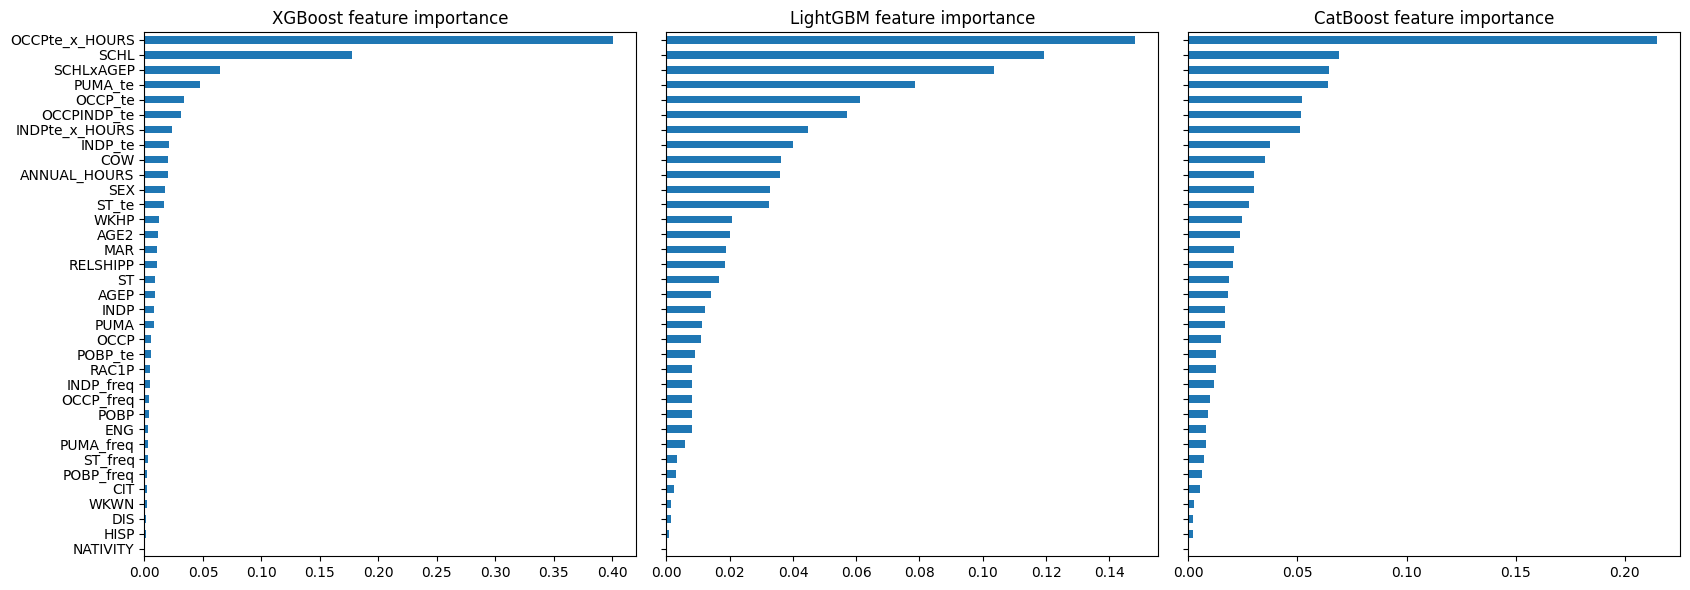

In [24]:
# Feature importance per TREE model (normalised to sum=1 so the three are comparable).
# The linear baselines are excluded here: their "importance" lives in hundreds of
# post-one-hot coefficients, not the 12 raw features, so they aren't directly comparable.
TREE_MODELS = {k: MODELS[k] for k in ("XGBoost", "LightGBM", "CatBoost")}
fig, ax = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
for a, (name, (m, _, _)) in zip(ax, TREE_MODELS.items()):
    imp = pd.Series(m.get_feature_importance() if name == "CatBoost"
                    else m.feature_importances_, index=list(X_train.columns))
    (imp / imp.sum()).sort_values().plot(kind="barh", ax=a)
    a.set_title(f"{name} feature importance")
plt.tight_layout(); plt.show()

## Stage 11b — Geography ablation (same split): PUMA-off vs. ST x PUMA

The Stage-11 table vs. the old v1 run is confounded -- v1 and v2 are *different* 25% samples,
so any +/-0.01 swing is resampling noise, not the feature. This stage isolates the geography
signal cleanly: **identical rows, identical CatBoost config, identical leak-safe per-column
target/frequency encoding** -- only the geography representation changes:

| Variant | Geography features |
|---|---|
| `off`  | `ST` only (PUMA dropped entirely) -- baseline |
| `bare` | `ST` + raw `PUMA` code (collides across states) -- what the headline run uses |
| `loc`  | `ST` + an `ST x PUMA` combined locality key (`ST*100000 + PUMA`) -- the proper key |

To keep the comparison controlled, this ablation uses a **streamlined** per-column encoding
(no `OCCP x INDP` pair-enc / `te x hours` interactions); those are geography-independent and held
constant, so read the **deltas (ΔR2)**, not the absolute level. A near-zero Δ means PUMA adds
little beyond `ST` + the other predictors -- i.e. the ceiling really is feature-bound.

In [25]:
# === Stage 11b -- clean same-split geography ablation ========================
import time
from sklearn.model_selection import KFold

GEN_COLS  = ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']
BASE_CONT = CONTINUOUS_COLS + GEN_COLS
BASE_CAT  = [c for c in CATEGORICAL_COLS if c != 'PUMA']   # ST stays; PUMA handled per-variant
ABL_SMOOTH = SMOOTH                                        # same shrink as Stage 6b (20.0)

# Reuse the EXACT Stage-6 split indices -> identical rows across every variant.
idx_tr, idx_va, idx_te = X_train.index, X_val.index, X_test.index

def _smoothed(xc, yc, col, smooth, gmean):
    g = yc.groupby(xc[col]); m = g.mean(); n = g.count()
    return (m * n + gmean * smooth) / (n + smooth)

def _add_loc(f):
    f['LOC'] = f['ST'].astype('int64') * 100000 + f['PUMA'].astype('int64')

def _build(cat_cols, te_cols, derive=None):
    # per-split feature frames with leak-safe te/freq encodings for te_cols
    tr = useful_feats_X.loc[idx_tr].copy()
    va = useful_feats_X.loc[idx_va].copy()
    te = useful_feats_X.loc[idx_te].copy()
    if derive:
        for f in (tr, va, te): derive(f)
    gmean = float(y_train.mean())
    for col in te_cols: tr[col + '_te'] = np.nan
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for sub, oof in kf.split(tr):                          # out-of-fold on train only
        s_idx, o_idx = tr.index[sub], tr.index[oof]
        for col in te_cols:
            fmap = _smoothed(tr.loc[s_idx], y_train.loc[s_idx], col, ABL_SMOOTH, gmean)
            tr.loc[o_idx, col + '_te'] = tr.loc[o_idx, col].map(fmap).fillna(gmean)
    full = {c: _smoothed(tr, y_train, c, ABL_SMOOTH, gmean) for c in te_cols}
    freq = {c: tr[c].value_counts(normalize=True) for c in te_cols}
    for f in (va, te):
        for c in te_cols: f[c + '_te'] = f[c].map(full[c]).fillna(gmean)
    for f in (tr, va, te):
        for c in te_cols: f[c + '_freq'] = f[c].map(freq[c]).fillna(0.0)
    use = BASE_CONT + cat_cols + [c + '_te' for c in te_cols] + [c + '_freq' for c in te_cols]
    return tr[use], va[use], te[use]

def _score(cat_cols, te_cols, derive=None):
    Xtr, Xva, Xte = _build(cat_cols, te_cols, derive)
    cats = [c for c in cat_cols if c in Xtr.columns]
    model = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=10,
                              loss_function='RMSE', eval_metric='RMSE',
                              random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0)
    t0 = time.time()
    model.fit(Pool(Xtr, y_train, cat_features=cats),
              eval_set=Pool(Xva, y_val, cat_features=cats), use_best_model=True)
    dt = time.time() - t0
    def metrics(Xs, yraw):
        p = np.expm1(model.predict(Xs)) * WAGP_TO_DOLLARS
        yt = yraw.values * WAGP_TO_DOLLARS
        return r2_score(yt, p), mean_absolute_error(yt, p)
    tr_r2, _      = metrics(Xtr, y_train_raw)
    te_r2, te_mae = metrics(Xte, y_test_raw)
    return dict(n_cols=Xtr.shape[1], best_iter=model.get_best_iteration(),
                secs=round(dt, 0), train_r2=tr_r2, test_r2=te_r2, test_mae=te_mae)

VARIANTS = {
    'off  (ST only)'     : dict(cat_cols=BASE_CAT,            te_cols=['OCCP','INDP','POBP','ST']),
    'bare (ST + PUMA)'   : dict(cat_cols=BASE_CAT + ['PUMA'], te_cols=['OCCP','INDP','POBP','ST','PUMA']),
    'loc  (ST + STxPUMA)': dict(cat_cols=BASE_CAT + ['LOC'],  te_cols=['OCCP','INDP','POBP','ST','LOC'],
                                derive=_add_loc),
}

abl = {}
for name, spec in VARIANTS.items():
    print(f'>> training variant: {name} ...', flush=True)
    abl[name] = _score(**spec)

abl_df = pd.DataFrame(abl).T
base_r2 = abl_df.loc['off  (ST only)', 'test_r2']
abl_df['dR2_vs_off'] = abl_df['test_r2'] - base_r2
abl_df = abl_df[['n_cols','best_iter','secs','train_r2','test_r2','dR2_vs_off','test_mae']]
print('\n=== Geography ablation (CatBoost, identical v2 split) ===')
print(abl_df.round({'train_r2':4,'test_r2':4,'dR2_vs_off':4,'test_mae':0}).to_string())
print('\nReading: dR2_vs_off is the clean, same-split effect of the geography encoding.')
print('Near-zero => PUMA adds little beyond ST + the other features (feature-bound ceiling).')


>> training variant: off  (ST only) ...


>> training variant: bare (ST + PUMA) ...


>> training variant: loc  (ST + STxPUMA) ...



=== Geography ablation (CatBoost, identical v2 split) ===
                     n_cols  best_iter   secs  train_r2  test_r2  dR2_vs_off  test_mae
off  (ST only)         29.0     1863.0  240.0    0.5430   0.4942      0.0000   28242.0
bare (ST + PUMA)       32.0     1723.0  213.0    0.5562   0.5063      0.0121   27948.0
loc  (ST + STxPUMA)    32.0     1580.0  449.0    0.5695   0.5057      0.0115   27905.0

Reading: dR2_vs_off is the clean, same-split effect of the geography encoding.
Near-zero => PUMA adds little beyond ST + the other features (feature-bound ceiling).


## Stage 12 — Model Saving & Inference

Persist **all ten** fitted models (three linear pipelines, three boosters, RandomForest/ExtraTrees/HistGB, and the stacking blender) plus the shared preprocessing metadata (feature list, categorical columns, target transform, dollar scale) so inference reproduces the exact pipeline (saved as `acs2024_income_models_exp2.pkl`, including the encoding maps). The best model by Test R² is used for the sanity-check prediction.

> **Note:** the `Stacking(GBMs)` entry is a `StackedGBM` instance; reloading the bundle in a *fresh* process needs that class definition in scope (re-run Stage 8, or move the class into an importable module before deploying).

In [26]:
# import joblib

# best_name = results_df.loc[results_df["Test R2"].idxmax(), "Algorithm"]
# bundle = {
#     "models": {n: t[0] for n, t in MODELS.items()},
#     "best_model": best_name,
#     "features": list(X_train.columns),
#     "cat_features": CAT_FEATURES,
#     "target": TARGET_COLUMN,
#     "target_transform": "log1p / expm1",
#     "wagp_to_dollars": WAGP_TO_DOLLARS,
#     "generated_features": GENERATED_COLS,
#     "encoding_cols": ENC_COLS,
#     "target_enc_maps": full_maps,         # incl. the OCCPxINDP pair map
#     "freq_maps": freq_maps,
#     "global_mean": GLOBAL_MEAN, "smooth": SMOOTH, "pair_smooth": PAIR_SMOOTH,
#     "survey_year": "2024",
#     "results": results_df,
# }
# joblib.dump(bundle, "acs2024_income_models_exp4.pkl")
# print("Saved acs2024_income_models_exp4.pkl | best model:", best_name)

# # Reload and predict on a sample with the best model (invert log1p, x1e6 -> dollars).
# loaded = joblib.load("acs2024_income_models_exp4.pkl")
# m, X_tr, X_te = MODELS[loaded["best_model"]]
# scale = loaded["wagp_to_dollars"]
# sample_pred = np.expm1(m.predict(X_te[:5])) * scale
# print("\nGround-truth WAGP:", [f"${v:,.0f}" for v in y_test_raw.values[:5] * scale])
# print("Predicted   WAGP:", [f"${v:,.0f}" for v in sample_pred])

---
## Experiment Log — EXP4 + PUMA geography (v2 dataset)

Ten regressors on the exp2/exp4 augmented set (Mincer `AGE2`/`SCHLxAGEP`, the `OCCP`x`INDP` pair target-encoding, `te x hours` interactions, and a six-tree Ridge-meta stack), now on **`acs2024v2_income.csv`** with the new **`PUMA`** sub-state geography feature added as a high-cardinality categorical (native + target/frequency encoded, parallel to `ST`). MAE/RMSE in dollars; R2 scale-free. Best Test R2 in **bold**.

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|
| Ridge | exp4 + PUMA (native + te/freq) | 31,022.21 | 60,856.14 | 0.46 | 31,388.33 | 62,699.51 | 0.44 |
| Linear | exp4 + PUMA (native + te/freq) | 31,184.18 | 60,639.74 | 0.46 | 31,336.08 | 62,815.63 | 0.43 |
| Lasso | exp4 + PUMA (native + te/freq) | 31,733.87 | 62,802.95 | 0.42 | 31,790.95 | 63,379.95 | 0.42 |
| XGBoost | exp4 + PUMA (native + te/freq) | 19,099.57 | 36,184.58 | 0.81 | 28,526.30 | 60,398.02 | 0.48 |
| LightGBM | exp4 + PUMA (native + te/freq) | 24,923.25 | 49,609.03 | 0.64 | 28,261.59 | 59,146.79 | 0.50 |
| CatBoost | exp4 + PUMA (native + te/freq) | 26,463.54 | 54,418.89 | 0.57 | 27,926.73 | 58,663.81 | 0.51 |
| RandomForest | exp4 + PUMA (native + te/freq) | 17,887.34 | 41,609.38 | 0.75 | 28,745.90 | 59,979.04 | 0.48 |
| ExtraTrees | exp4 + PUMA (native + te/freq) | 16,838.57 | 39,306.74 | 0.77 | 28,255.07 | 59,543.53 | 0.49 |
| HistGradientBoosting | exp4 + PUMA (native + te/freq) | 26,409.39 | 53,544.22 | 0.58 | 28,203.52 | 59,087.90 | 0.50 |
| **Stacking(GBMs)** | exp4 + PUMA (native + te/freq) | 24,119.35 | 49,175.07 | 0.65 | **27,824.02** | **58,502.16** | **0.51** |

**Headline:** best Test **R2 ~= 0.509** (`Stacking(GBMs)`) / 0.506 (`CatBoost`). This is statistically unchanged from the pre-PUMA exp4 (~0.508) -- but that cross-run comparison is **confounded** (v1 vs v2 are different 25% samples), so it understates PUMA. The clean number is the same-split ablation below.

### Geography ablation (Stage 11b) -- clean same-split CatBoost

Identical rows / CatBoost config / leak-safe encoding; **only the geography representation changes** (streamlined per-column encoding, so read the deltas not the level).

| Variant | Geography | Test R2 | ΔR2 vs off | Test MAE |
|---|---|---|---|---|
| `off`  | `ST` only (no PUMA) | 0.4942 | -- | 28,242 |
| `bare` | `ST` + raw `PUMA` | **0.5063** | **+0.0121** | 27,948 |
| `loc`  | `ST` + `ST x PUMA` key | 0.5057 | +0.0115 | 27,905 |

**Verdict:**
1. **PUMA gives a small but real ~+0.012 R2 lift** (0.494 -> 0.506) on the identical split -- the "flat" cross-run read was a resampling artifact, not the truth.
2. **The `ST x PUMA` combined key adds nothing over bare `PUMA`** (0.5057 vs 0.5063) and overfits slightly more (train 0.570 vs 0.556) -- CatBoost already combines raw `PUMA` + raw `ST` internally. **Use bare `PUMA` as a native categorical.**
3. Geography helps at the margin; the ceiling stays mostly **feature-bound (~0.51)**.
